# Ejercicio análisis time series
Para este ejercicio vas a trabajar con el histórico de valores en bolsa de una empresa que se dedica a vender muebles. Se pide
1. Importa los datos `df_furniture.csv`
2. Trata la fecha como texto. Crea una columna para el año, mes y dia, y a partir de esas columnas crea la de fecha, en formato datetime de pandas
3. ¿De qué fecha a qué fecha va el histórico?
4. ¿Cómo es la serie temporal? ¿Tiene tendencia? ¿Aprecias alguna estacionalidad?
5. ¿Podrías demostrar de dos maneras estadísticas que la serie no es stationary?
6. Parece que hay una tendencia, pero no se aprecia bien con tanto pico en la serie. ¿Conoces algún método para representar mejor la tendencia?
7. Estaría bien visualizar todos los componentes de la serie temporal por separado
8. Demuestra mediante una gráfica de autocorrelación que la serie es estacional
9. ¿Qué dependencia tiene cada instante de sus últimos 5 lags? Demuéstralo mediante una matriz de correlación. ¿Esto es bueno para los modelos?
10. Ya hemos visto que hay estacionalidad. ¿Cada cuántos instantes se cumple ese patrón?
11. Para un futuro modelado de los datos necesitaremos eliminar la tendencia. ¿Cómo hacemos esto?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Cargamos los datos

In [3]:
df = pd.read_csv('data/df_furniture.csv', parse_dates = ['Month'])
df.head(20)

,Month,furniture_price_adjusted
0,1992-01-01,2073.432724
1,1992-02-01,2114.485812
2,1992-03-01,2260.570891
3,1992-04-01,2255.103236
4,1992-05-01,2331.414618
5,1992-06-01,2384.638567
6,1992-07-01,2417.165376
7,1992-08-01,2445.498729
8,1992-09-01,2387.351705
9,1992-10-01,2489.350838


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 331 entries, 0 to 330
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Month                     326 non-null    datetime64[us]
 1   furniture_price_adjusted  331 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 5.3 KB


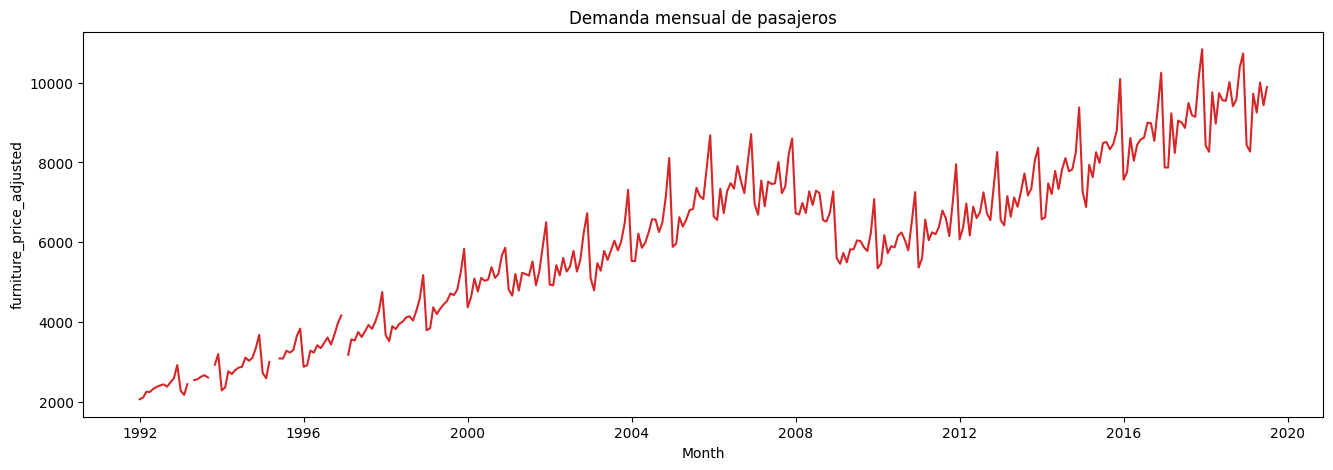

In [5]:
def plot_df(df, x, y, title='', xlabel='Month', ylabel='furniture_price_adjusted', dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()

plot_df(df, x=df['Month'], y=df['furniture_price_adjusted'], title='Demanda mensual de pasajeros')

Arreglamos la columna Month, para rellenar los nulos

In [6]:
while df['Month'].isna().any():
    # Encontrar el índice del NaT
    i = df['Month'].isna().idxmax()

    # Rellenar con el mes siguiente al anterior
    if i == 0:
        df.loc[i, 'Month'] = df.loc[i + 1, 'Month'] - pd.DateOffset(months=1)

    # Caso 2: NaT en cualquier otra fila
    else:
        df.loc[i, 'Month'] = df.loc[i - 1, 'Month'] + pd.DateOffset(months=1)

df.head(20)

,Month,furniture_price_adjusted
0,1992-01-01,2073.432724
1,1992-02-01,2114.485812
2,1992-03-01,2260.570891
3,1992-04-01,2255.103236
4,1992-05-01,2331.414618
5,1992-06-01,2384.638567
6,1992-07-01,2417.165376
7,1992-08-01,2445.498729
8,1992-09-01,2387.351705
9,1992-10-01,2489.350838


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 331 entries, 0 to 330
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Month                     331 non-null    datetime64[us]
 1   furniture_price_adjusted  331 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 5.3 KB


## 2. Tratar la fecha como texto e interpretar (parse)

In [8]:
df['year'] = df['Month'].dt.year
df['month'] = df['Month'].dt.month
df['day'] = df['Month'].dt.day

# Recreamos la columna fecha desde texto
df['fecha'] = pd.to_datetime(df[['year', 'month', 'day']])

df.head()

,Month,furniture_price_adjusted,year,month,day,fecha
0,1992-01-01,2073.432724,1992,1,1,1992-01-01
1,1992-02-01,2114.485812,1992,2,1,1992-02-01
2,1992-03-01,2260.570891,1992,3,1,1992-03-01
3,1992-04-01,2255.103236,1992,4,1,1992-04-01
4,1992-05-01,2331.414618,1992,5,1,1992-05-01


## 3. ¿De qué fecha a qué fecha va el histórico?

In [9]:
print('Fecha inicio:', df['Month'].min())
print('Fecha fin:   ', df['Month'].max())
print('Duración:    ', df['Month'].max() - df['Month'].min())

Fecha inicio: 1992-01-01 00:00:00
Fecha fin:    2019-07-01 00:00:00
Duración:     10043 days 00:00:00


## 4. ¿Cómo es la serie temporal? ¿Tiene tendencia? ¿Aprecias alguna estacionalidad?

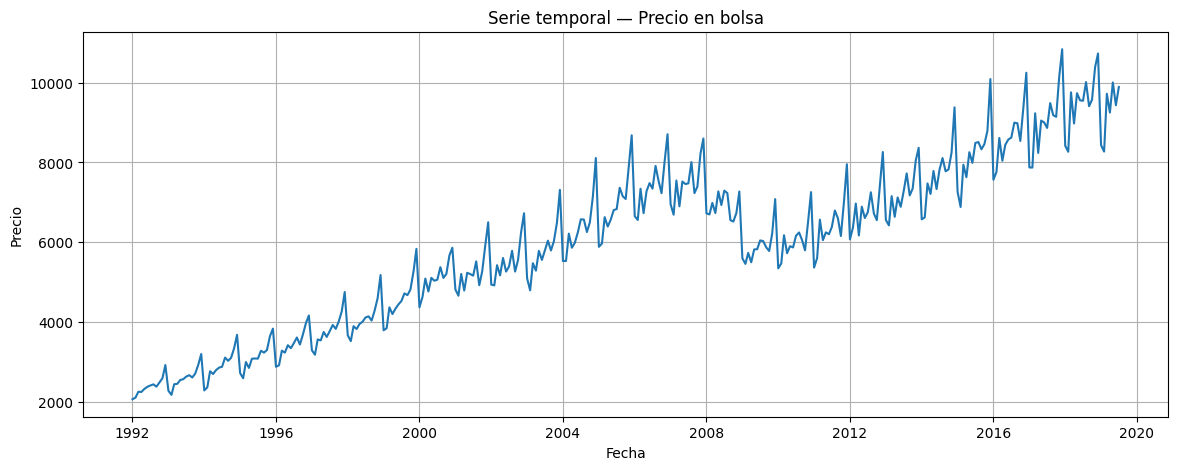

In [10]:
plt.figure(figsize=(14, 5))
plt.plot(df['Month'], df['furniture_price_adjusted'])
plt.title('Serie temporal — Precio en bolsa')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.grid(True);

Se ve claramente una tendencia ascendente con estacionalidad anual, con picos periódicos.

## 5. ¿Podrías demostrar de dos maneras estadísticas que la serie no es estacionaria?

Tenemos varios métodos: ADF, PP, ERS y la prueba KPSS.

Usaremos ADF y KPSS.

In [11]:
from statsmodels.tsa.stattools import adfuller, kpss

# ADF Test
adf_result = adfuller(df['furniture_price_adjusted'])
print('ADF Test')
print(f'Estadístico: {adf_result[0]:.4f}')
print(f'p-valor:     {adf_result[1]:.4f}')
print('→ No estacionaria' if adf_result[1] > 0.05 else '→ Estacionaria')

# KPSS Test
kpss_result = kpss(df['furniture_price_adjusted'], regression='c')
print('\nKPSS Test')
print(f'Estadístico: {kpss_result[0]:.4f}')
print(f'p-valor:     {kpss_result[1]:.4f}')
print('→ No estacionaria' if kpss_result[1] < 0.05 else '→ Estacionaria')

ADF Test
Estadístico: -1.1286
p-valor:     0.7036
→ No estacionaria

KPSS Test
Estadístico: 2.5552
p-valor:     0.0100
→ No estacionaria


C:\Users\urkow\AppData\Local\Temp\ipykernel_30324\4094612097.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(df['furniture_price_adjusted'], regression='c')


## 6. ¿Conoces algún método para representar mejor la tendencia?

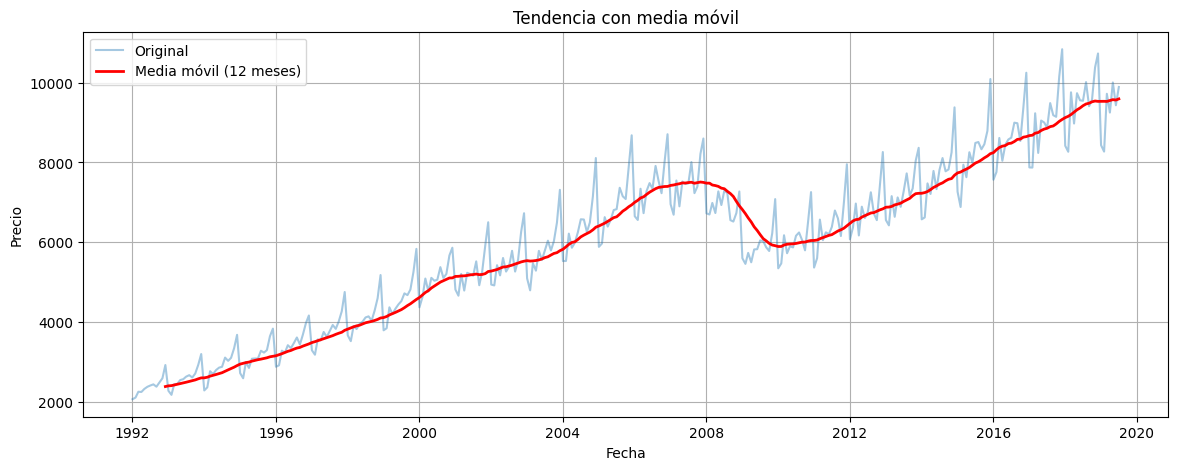

In [12]:
df['rolling_mean'] = df['furniture_price_adjusted'].rolling(window=12).mean()

plt.figure(figsize=(14, 5))
plt.plot(df['Month'], df['furniture_price_adjusted'], alpha=0.4, label='Original')
plt.plot(df['Month'], df['rolling_mean'], color='red', linewidth=2, label='Media móvil (12 meses)')
plt.title('Tendencia con media móvil')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.grid(True);

## 7. Estaría bien visualizar todos los componentes de la serie temporal por separado

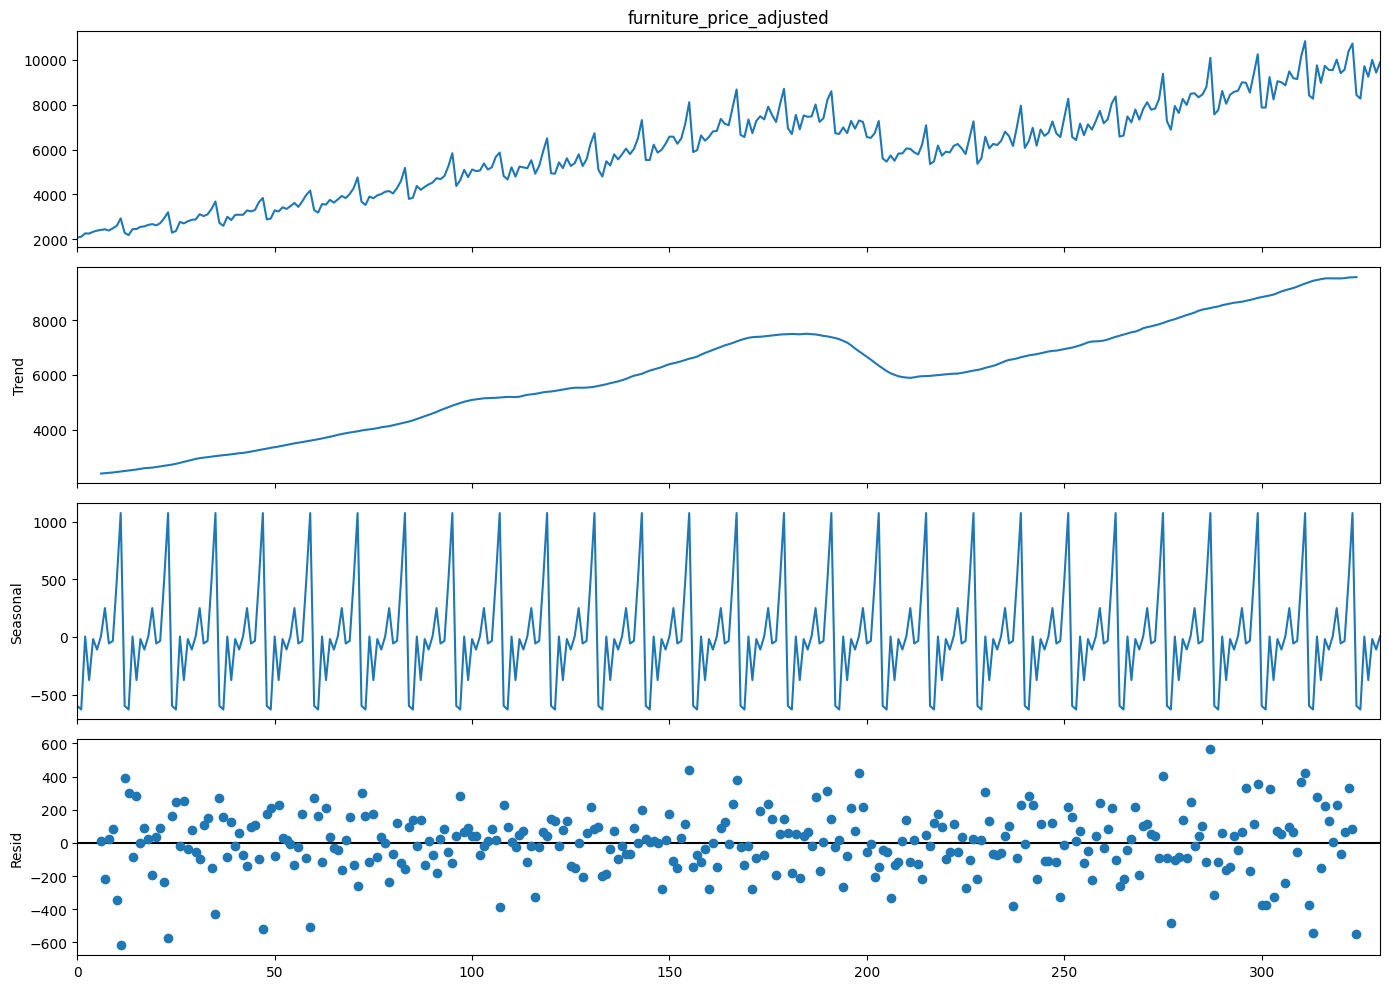

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Additive
descomposicion = seasonal_decompose(df['furniture_price_adjusted'], model='additive', period=12)

fig = descomposicion.plot()
fig.set_size_inches(14, 10)
plt.tight_layout();

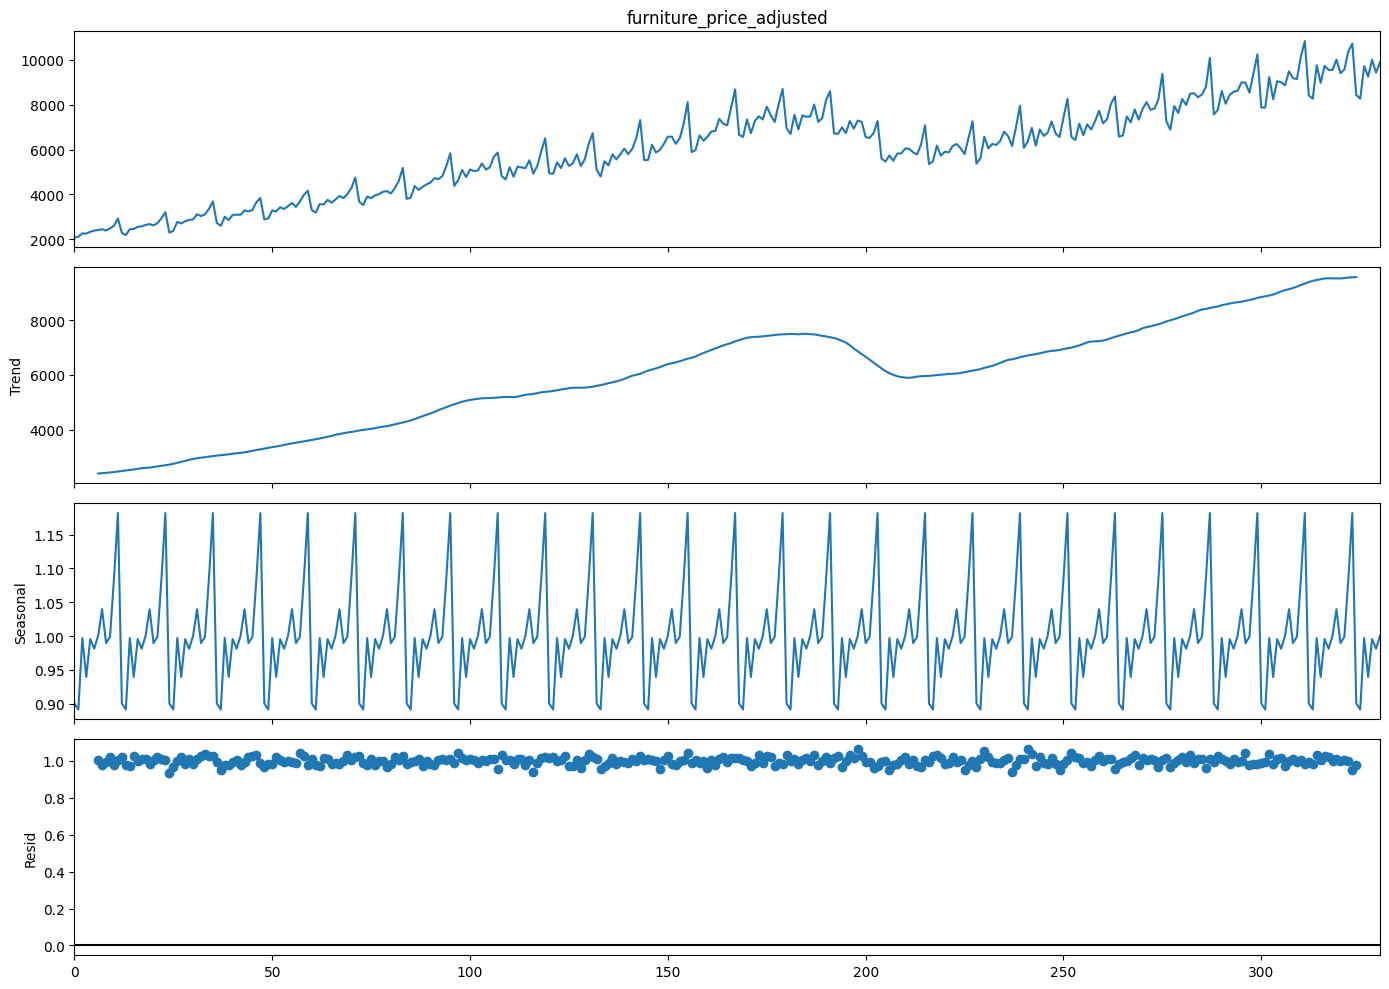

In [14]:
# Multiplicative
descomposicion = seasonal_decompose(df['furniture_price_adjusted'], model='multiplicative', period=12)

fig = descomposicion.plot()
fig.set_size_inches(14, 10)
plt.tight_layout();

## 8. Demuestra mediante una gráfica de autocorrelación que la serie es estacional

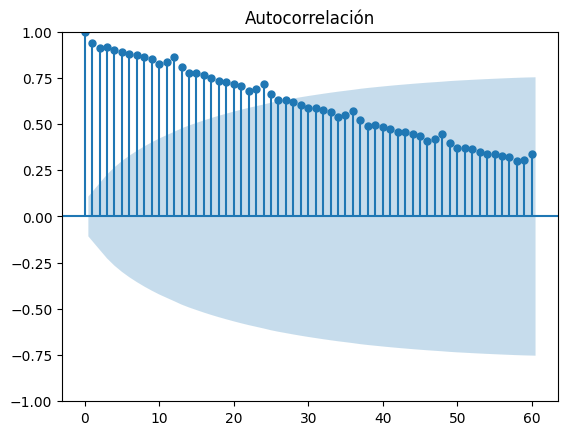

In [16]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['furniture_price_adjusted'].values, lags=60)
plt.title('Autocorrelación');

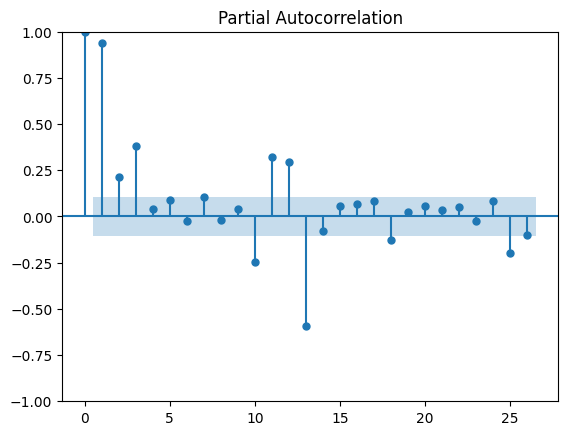

In [18]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df['furniture_price_adjusted'].values);

## 9. ¿Qué dependencia tiene cada instante de sus últimos 5 lags? Demuéstralo mediante una matriz de correlación.

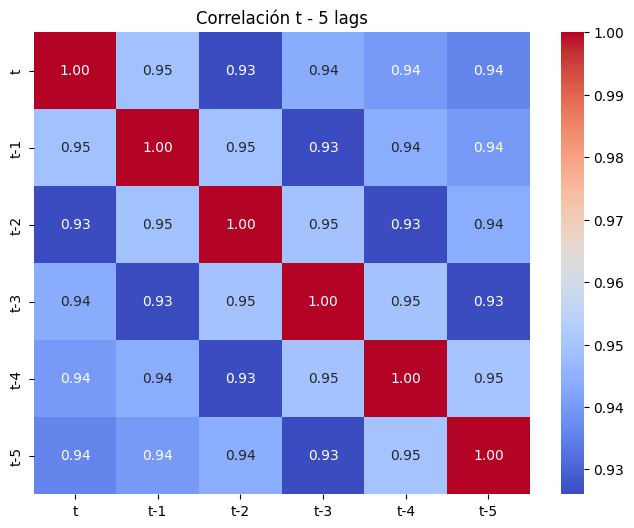

In [25]:
df_lags = pd.DataFrame({'t': df['furniture_price_adjusted']})
for i in range(1, 6):
    df_lags[f't-{i}'] = df['furniture_price_adjusted'].shift(i)

df_lags = df_lags.dropna()

# Matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(df_lags.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlación t - 5 lags');

## 10. Ya hemos visto que hay estacionalidad. ¿Cada cuántos instantes se cumple ese patrón?

In [26]:
from statsmodels.graphics.tsaplots import plot_acf

acf_values = pd.Series(
    [df['furniture_price_adjusted'].autocorr(lag=i) for i in range(1, 49)],
    index=range(1, 49)
)

print('Lags con mayor autocorrelación:')
print(acf_values.nlargest(5))

Lags con mayor autocorrelación:
12    0.980982
1     0.951005
3     0.945035
24    0.941047
4     0.940613
dtype: float64


## 11. Para un futuro modelado de los datos necesitaremos eliminar la tendencia. ¿Cómo hacemos esto?

ADF p-valor tras diferenciar: 0.0253
Resultado → Estacionaria


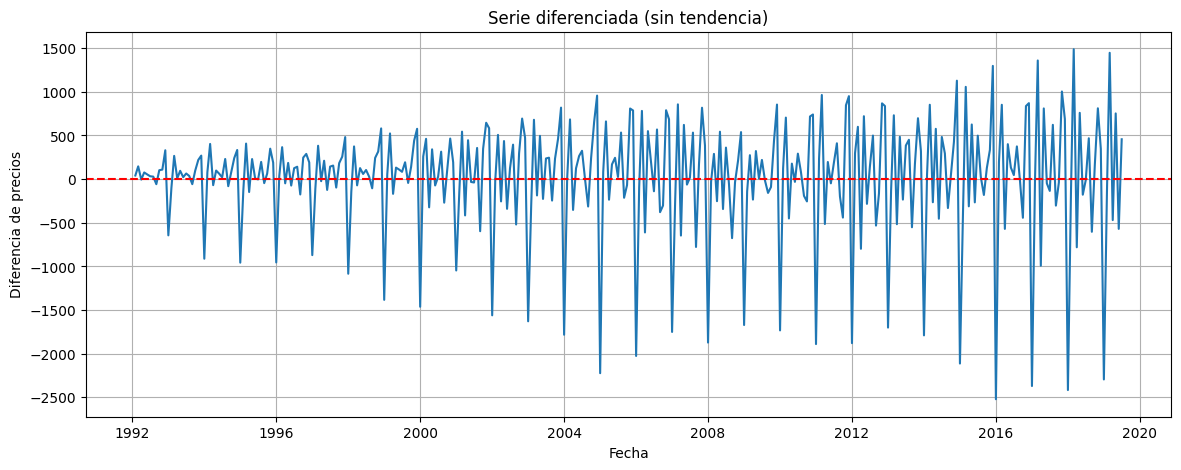

In [31]:
df['precio_diff'] = df['furniture_price_adjusted'].diff()

plt.figure(figsize=(14, 5))
plt.plot(df['Month'], df['precio_diff'])
plt.title('Serie diferenciada (sin tendencia)')
plt.xlabel('Fecha')
plt.ylabel('Diferencia de precios')
plt.axhline(0, color='red', linestyle='--')
plt.grid(True);

# Verificamos que ahora sí es estacionaria
adf_diff = adfuller(df['precio_diff'].dropna())
print(f'ADF p-valor tras diferenciar: {adf_diff[1]:.4f}')
print('Resultado → Estacionaria' if adf_diff[1] < 0.05 else 'Resultado → Sigue sin ser estacionaria')